In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(transform_output= "pandas")
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
df = pd.read_csv("wnbadraft.csv")
df

,overall_pick,year,team,player,former,college,years_played,games,win_shares,win_shares_40,minutes_played,points,total_rebounds,assists
0,1,2022,Atlanta Dream,Rhyne Howard,NaN,Kentucky,1,34.0,2.9,0.110,31.4,16.2,4.5,2.8
1,2,2022,Indiana Fever,NaLyssa Smith,NaN,Baylor,1,32.0,0.0,-0.001,30.7,13.5,7.9,1.4
2,3,2022,Washington Mystics,Shakira Austin,NaN,Ole Miss,1,36.0,3.1,0.160,21.6,8.7,6.5,0.9
3,4,2022,Indiana Fever,Emily Engstler,NaN,Louisville,1,35.0,0.4,0.024,18.2,5.2,5.2,1.5
4,5,2022,New York Liberty,Nyara Sabally,NaN,Oregon,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,28,1997,Utah Starzz,Kim Williams,NaN,DePaul,2,58.0,0.3,0.010,19.8,7.8,2.4,1.8
1060,29,1997,Cleveland Rockers,Anita Maxwell,NaN,New Mexico State,1,9.0,-0.1,-0.036,7.0,2.1,1.3,0.9
1061,30,1997,Los Angeles Sparks,Travesa Gant,NaN,Lamar,1,2.0,-0.1,-0.247,6.5,0.0,1.5,0.0
1062,31,1997,Sacramento Monarchs,Tajama Abraham,NaN,George Washington,2,40.0,-0.8,-0.070,11.7,3.5,1.9,0.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   overall_pick    1064 non-null   int64  
 1   year            1064 non-null   int64  
 2   team            1064 non-null   object 
 3   player          1062 non-null   object 
 4   former          125 non-null    object 
 5   college         978 non-null    object 
 6   years_played    1064 non-null   int64  
 7   games           730 non-null    float64
 8   win_shares      730 non-null    float64
 9   win_shares_40   729 non-null    float64
 10  minutes_played  730 non-null    float64
 11  points          730 non-null    float64
 12  total_rebounds  730 non-null    float64
 13  assists         730 non-null    float64
dtypes: float64(7), int64(3), object(4)
memory usage: 116.5+ KB


## EDA

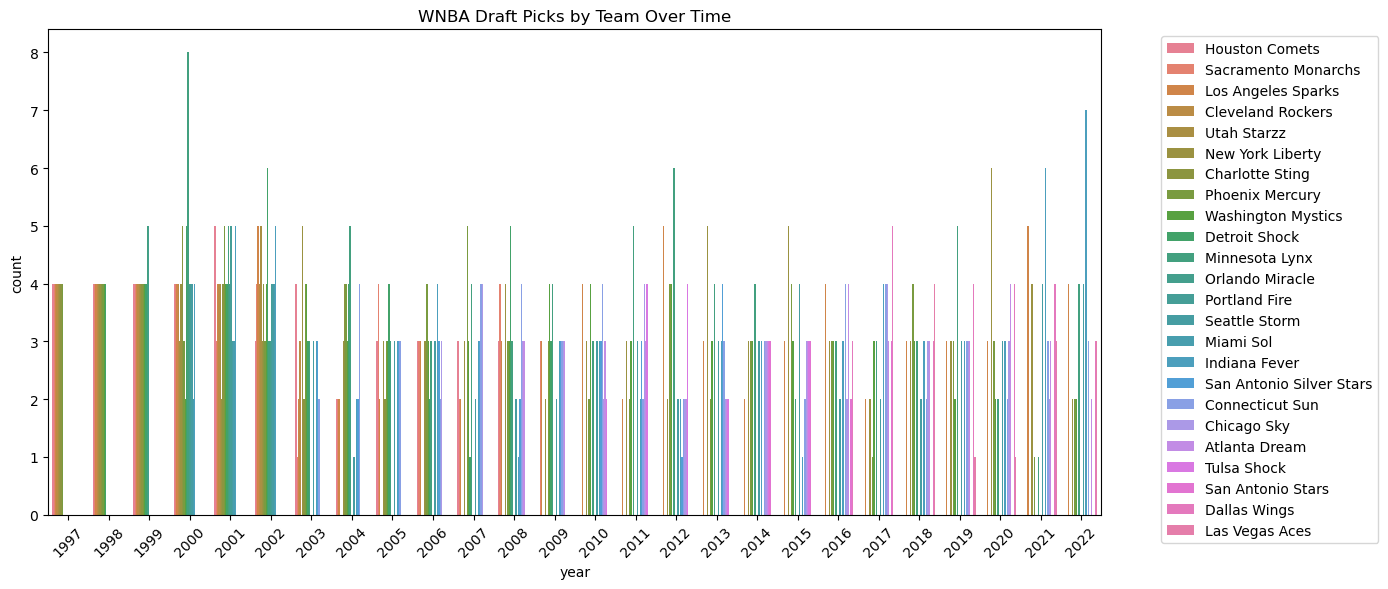

In [5]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x="year", hue="team")
plt.title("WNBA Draft Picks by Team Over Time")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

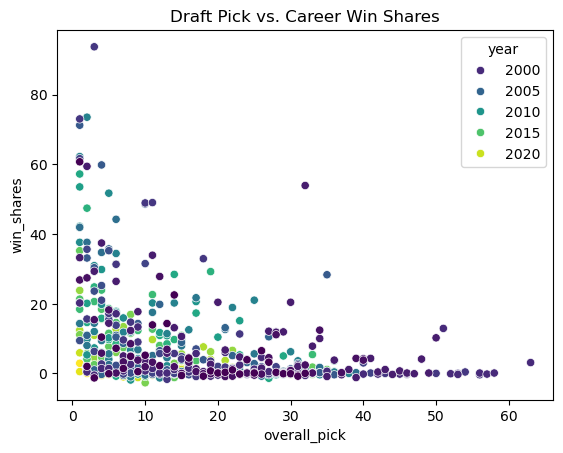

In [6]:
sns.scatterplot(data=df, x="overall_pick", y="win_shares", hue="year", palette="viridis")
plt.title("Draft Pick vs. Career Win Shares")
plt.show()

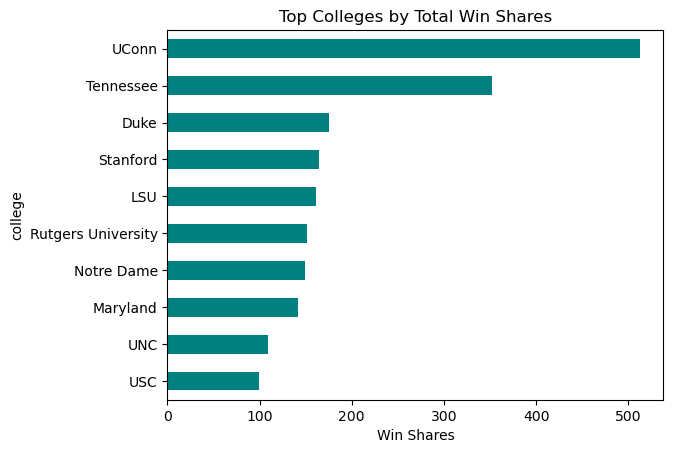

In [7]:
top_colleges = df.groupby("college")["win_shares"].sum().sort_values(ascending=False).head(10)
top_colleges.plot(kind="barh", color="teal")
plt.title("Top Colleges by Total Win Shares")
plt.xlabel("Win Shares")
plt.gca().invert_yaxis()
plt.show()

In [8]:
df.describe()

,overall_pick,year,years_played,games,win_shares,win_shares_40,minutes_played,points,total_rebounds,assists
count,1064.000000,1064.000000,1064.000000,730.000000,730.000000,729.000000,730.000000,730.000000,730.000000,730.000000
mean,21.949248,2008.596805,3.095865,116.106849,6.120548,0.024898,14.885205,5.011781,2.394110,1.150411
std,13.789960,7.502776,3.761745,118.514130,11.894051,0.166591,7.983228,4.019906,1.750354,1.063798
min,1.000000,1997.000000,0.000000,1.000000,-2.700000,-2.948000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,2002.000000,0.000000,24.000000,0.000000,-0.005000,8.200000,2.025000,1.100000,0.400000
50%,21.000000,2008.000000,2.000000,70.000000,1.000000,0.052000,13.900000,3.950000,2.000000,0.900000
75%,31.000000,2015.000000,5.000000,172.250000,6.500000,0.095000,21.000000,7.000000,3.100000,1.600000
max,64.000000,2022.000000,19.000000,580.000000,93.700000,0.463000,34.700000,20.300000,9.800000,6.600000


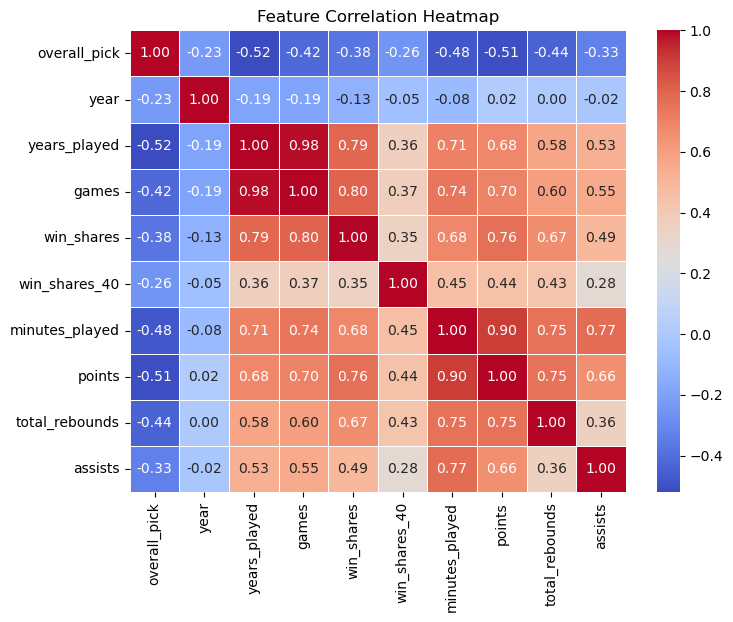

In [9]:
corr_matrix = df.corr(numeric_only=True)  
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
df.isna().sum()

overall_pick        0
year                0
team                0
player              2
former            939
college            86
years_played        0
games             334
win_shares        334
win_shares_40     335
minutes_played    334
points            334
total_rebounds    334
assists           334
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns


Index(['overall_pick', 'year', 'team', 'player', 'former', 'college',
       'years_played', 'games', 'win_shares', 'win_shares_40',
       'minutes_played', 'points', 'total_rebounds', 'assists'],
      dtype='object')

In [13]:
from sklearn.model_selection import train_test_split

# Drop all rows with missing target values
df_clean = df.dropna(subset=['win_shares'])

#crreate test data
W_test = df_clean[df_clean["year"] == 2022]
W_test.to_csv('W_test.csv')

df_clean = df.dropna(subset=['win_shares'])


# Define target and features
y = df_clean['win_shares']

# Define feature columns explicitly
feature_cols = ['overall_pick', 'year', 'team', 'player', 'former', 'college',
                'win_shares_40', 'minutes_played', 'points', 'total_rebounds',
                'assists', 'years_played', 'games']

# Create feature matrix
X = df_clean[feature_cols]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify column types for preprocessing
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [14]:
cat_cols

['team', 'player', 'former', 'college']

In [15]:
num_cols

['overall_pick',
 'year',
 'win_shares_40',
 'minutes_played',
 'points',
 'total_rebounds',
 'assists',
 'years_played',
 'games']

In [16]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])
# Fit the preprocessor
preprocessor.fit(X_train)

# Transform the data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [17]:
pd.set_option("display.max_columns", 1000)
X_train_transformed.head()

,num__overall_pick,num__year,num__win_shares_40,num__minutes_played,num__points,num__total_rebounds,num__assists,num__years_played,num__games,cat__team_Atlanta Dream,cat__team_Charlotte Sting,cat__team_Chicago Sky,cat__team_Cleveland Rockers,cat__team_Connecticut Sun,cat__team_Dallas Wings,cat__team_Detroit Shock,cat__team_Houston Comets,cat__team_Indiana Fever,cat__team_Las Vegas Aces,cat__team_Los Angeles Sparks,cat__team_Miami Sol,cat__team_Minnesota Lynx,cat__team_New York Liberty,cat__team_Orlando Miracle,cat__team_Phoenix Mercury,cat__team_Portland Fire,cat__team_Sacramento Monarchs,cat__team_San Antonio Silver Stars,cat__team_San Antonio Stars,cat__team_Seattle Storm,cat__team_Tulsa Shock,cat__team_Utah Starzz,cat__team_Washington Mystics,cat__player_Aaliyah Wilson,cat__player_Aari McDonald,cat__player_Abi Olajuwon,cat__player_Adia Barnes,cat__player_Adrienne Goodson,cat__player_Adut Bulgak,cat__player_Aerial Powers,cat__player_Aisha Sheppard,cat__player_Aiysha Smith,cat__player_Albena Branzova,cat__player_Aleah Goodman,cat__player_Alex Bentley,cat__player_Alex Harden,cat__player_Alex Montgomery,cat__player_Alexis Hornbuckle,cat__player_Alexis Jones,cat__player_Alexis Prince,cat__player_Alicia Thompson,cat__player_Alison Bales,cat__player_Alison Lacey,cat__player_Allie Quigley,cat__player_Allisha Gray,cat__player_Allison Feaster,cat__player_Allison Hightower,cat__player_Ally Malott,cat__player_Alysha Clark,cat__player_Alyssa Thomas,cat__player_Amanda Lassiter,cat__player_Amanda Thompson,cat__player_Amanda Wilson,cat__player_Amanda Zahui B.,cat__player_Amaya Valdemoro,cat__player_Amber Harris,cat__player_Amber Jacobs,cat__player_Ambrosia Anderson,cat__player_Ameryst Alston,cat__player_Amisha Carter,cat__player_Amy Atwell,cat__player_Andrea Congreaves,cat__player_Andrea Garner,cat__player_Andrea Hoover,cat__player_Andrea Lloyd-Curry,cat__player_Andrea Riley,cat__player_Angel McCoughtry,cat__player_Angela Jackson,cat__player_Angelina Williams,cat__player_Angelina Wolvert,cat__player_Angie Braziel,cat__player_Angie Hamblin,cat__player_Angie Potthoff,cat__player_Ann Wauters,cat__player_Anne Marie Armstrong,cat__player_Anriel Howard,cat__player_Arella Guirantes,cat__player_Arica Carter,cat__player_Ariel Atkins,cat__player_Arike Ogunbowale,cat__player_Armintie Herrington,cat__player_Ashley Battle,cat__player_Ashley Houts,cat__player_Ashley Robinson,cat__player_Ashley Shields,cat__player_Ashley Walker,cat__player_Asjha Jones,cat__player_Astou Ndiaye-Diatta,cat__player_Astou Ndour,cat__player_Azura Stevens,cat__player_Barbara Turner,cat__player_Bashaara Graves,cat__player_Beatrice Mompremier,cat__player_Bella Alarie,cat__player_Bernice Mosby,cat__player_Betnijah Laney,cat__player_Betty Lennox,cat__player_Brandi McCain,cat__player_Brandy Reed,cat__player_Breanna Lewis,cat__player_Breanna Stewart,cat__player_Brene Moseley,cat__player_Bria Holmes,cat__player_Briana Gilbreath-Butler,cat__player_Briann January,cat__player_Brianna Kiesel,cat__player_Bridget Carleton,cat__player_Brionna Jones,cat__player_Britany Miller,cat__player_Brittainey Raven,cat__player_Brittany Boyd,cat__player_Brittany Brewer,cat__player_Brittany Hrynko,cat__player_Brittney Griner,cat__player_Brittney Sykes,cat__player_Brooke Queenan,cat__player_Brooke Smith,cat__player_Brooke Wyckoff,cat__player_Camille Cooper,cat__player_Camille Little,cat__player_Candace Parker,cat__player_Candice Dupree,cat__player_Candice Wiggins,cat__player_Cappie Pondexter,cat__player_Carla McGhee,cat__player_Carla Thomas,cat__player_Carolyn Moos,cat__player_Carolyn Swords,cat__player_Carolyn Young,cat__player_Catarina Pollini,cat__player_Cathrine Kraayeveld,cat__player_Cathy Joens,cat__player_Chamique Holdsclaw,cat__player_Chandi Jones,cat__player_Chanel Mokango,cat__player_Chante Black,cat__player_Chantel Tremitiere,cat__player_Charli Collier,cat__player_Charlotte Smith,cat__player_Chastity Reed,cat__player_Chay Shegog,cat__player_Chelsea Dungee,cat__player_Chelsea Newton,cat__player_C

## Linear Regression Model

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_transformed, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_transformed)

# Evaluate
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))

mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
print("Linear Regression RMSE:", rmse)

Linear Regression R²: 0.75878848728238
Linear Regression RMSE: 5.661494419819122


## Random Forest Model

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_transformed, y_train)

y_pred_rf = rf_model.predict(X_test_transformed)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))

mse1 = mean_squared_error(y_test, y_pred_rf)
rmse1 = np.sqrt(mse1)
print("Random Forest RMSE:", rmse1)

Random Forest R²: 0.9599771554673479
Random Forest RMSE: 2.3061419897118944


## XGBosst Regressor Model

In [20]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_transformed, y_train)

y_pred_xgb = xgb_model.predict(X_test_transformed)

print("XGBoost R²:", r2_score(y_test, y_pred_xgb))

mse2 = mean_squared_error(y_test, y_pred_xgb)
rmse2 = np.sqrt(mse2)
print("XGBoost  RMSE:", rmse2)

XGBoost R²: 0.9663593773805372
XGBoost  RMSE: 2.1142876841304057


In [23]:
!pip install joblib

import joblib

from joblib import dump, load

print(joblib.dump(xgb_model, "Perfomanceprediction_model.pkl"))
print(joblib.dump(preprocessor, "Perfomanceprediction_preprocessor.pkl"))

['Perfomanceprediction_model.pkl']
['Perfomanceprediction_preprocessor.pkl']



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Testing the best model with new data

In [28]:
from joblib import load

model = load('Perfomanceprediction_model.pkl')
preprocessor = load('Perfomanceprediction_preprocessor.pkl')

w_test = pd.read_csv('w_test.csv')

X_new = preprocessor.transform(W_test.drop('win_shares', axis=1))
y_new = W_test['win_shares']

predictions = model.predict(X_new)

# Create results dataframe
results_df = pd.DataFrame({
    "Overall Pick": W_test["overall_pick"].values,
    "Actual win_shares": y_new.values,
    "Predicted win_shares": predictions
})

# Add prediction error
results_df["Error"] = results_df["Predicted win_shares"] - results_df["Actual win_shares"]

print("2022 Overall Pick Performance")
print(results_df)


2022 Overall Pick Performance
    Overall Pick  Actual win_shares  Predicted win_shares     Error
0              1                2.9              2.828341 -0.071659
1              2                0.0              0.086998  0.086998
2              3                3.1              3.670076  0.570076
3              4                0.4              0.446100  0.046100
4              6               -0.4             -0.320702  0.079298
5              7                0.9              0.881096 -0.018904
6              9               -0.1             -0.298814 -0.198814
7             10                0.0              0.147684  0.147684
8             11               -0.1             -0.198187 -0.098187
9             12                0.4              0.242310 -0.157690
10            13               -0.1             -0.260509 -0.160509
11            15                1.5              1.780645  0.280645
12            16               -0.2             -0.291823 -0.091823
13            17  